# Data Exploration — GNN Recommender Thesis\n\nExplores the preprocessed Amazon Toys & Games and CDs & Vinyl datasets.\nFigures are saved to `results/figures/` for inclusion in the report.\n\n> **Prerequisites**: run `python scripts/preprocess.py --dataset all` first to generate `data/processed/`.

In [4]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# Make sure project root is on the path
sys.path.insert(0, str(Path("..").resolve()))

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR   = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
COLORS = {"Toys & Games": "#4C72B0", "CDs & Vinyl": "#DD8452"}
KEYS   = {"Toys & Games": "toys",    "CDs & Vinyl": "cds"}

# Load both datasets
datasets = {}
for label, key in KEYS.items():
    with open(PROCESSED_DIR / key / "dataset.pkl", "rb") as f:
        datasets[label] = pickle.load(f)

print("Datasets loaded:", list(datasets.keys()))

Datasets loaded: ['Toys & Games', 'CDs & Vinyl']


## 1. Summary Statistics

In [12]:
rows = []
for label, ds in datasets.items():
    n_val   = len(ds.val)
    n_test  = len(ds.test)
    n_train = len(ds.train)
    n_total = n_train + n_val + n_test

    user_counts = ds.train.groupby("user_idx")["item_idx"].count()
    item_counts = ds.train.groupby("item_idx")["user_idx"].count()
    density = n_total / (ds.n_users * ds.n_items) * 100

    rows.append({
        "Dataset":          label,
        "Users":            ds.n_users,
        "Items":            ds.n_items,
        "Interactions":     n_total,
        "Sparcity":         1 - n_total / (ds.n_users * ds.n_items),
        "Density (%)":      round(density, 4),
        "Avg inter./user":  round(n_total / ds.n_users, 2),
        "Avg inter./item":  round(n_total / ds.n_items, 2),
        "Min inter./user":  int(user_counts.min()) + 2,
        "Max inter./user":  int(user_counts.max()) + 2,
    })

stats_df = pd.DataFrame(rows).set_index("Dataset")
stats_df.to_csv(FIGURES_DIR / "dataset_stats.csv")
stats_df

,Users,Items,Interactions,Sparcity,Density (%),Avg inter./user,Avg inter./item,Min inter./user,Max inter./user
Dataset,,,,,,,,,
Toys & Games,45925,33243,800725,0.999476,0.0524,17.44,24.09,10,1845
CDs & Vinyl,23059,20762,540118,0.998872,0.1128,23.42,26.01,10,1136


## 2. Dataset Scale Comparison

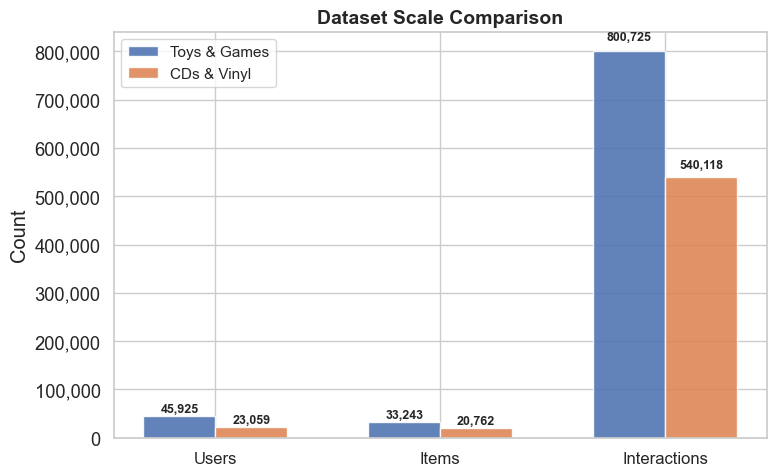

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Users", "Items", "Interactions"]
x = np.arange(len(categories))
width = 0.32

for i, (label, ds) in enumerate(datasets.items()):
    n_total = len(ds.train) + len(ds.val) + len(ds.test)
    values  = [ds.n_users, ds.n_items, n_total]
    bars = ax.bar(x + (i - 0.5) * width, values, width,
                  label=label, color=COLORS[label], alpha=0.88, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f"{val:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Dataset Scale Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "dataset_comparison.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "dataset_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. User Interaction Count Distribution

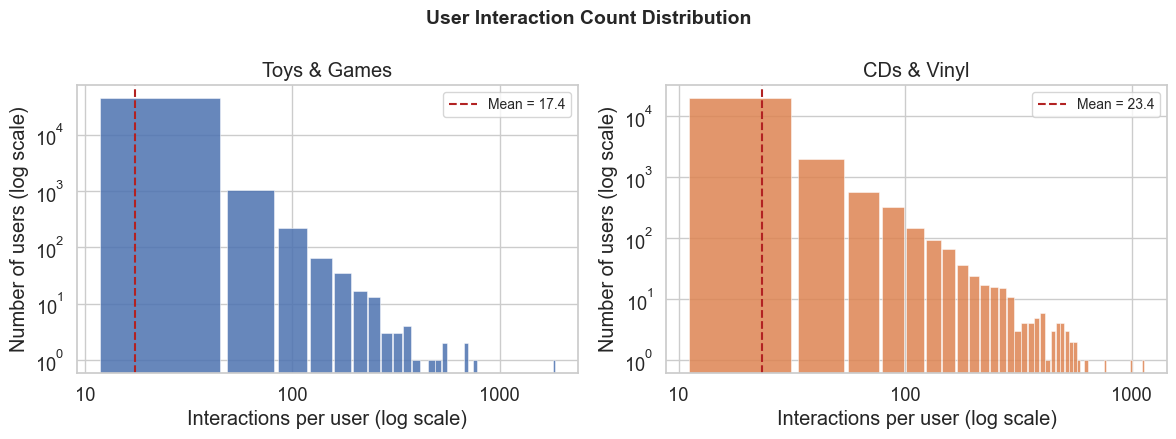

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (label, ds) in zip(axes, datasets.items()):
    user_counts = ds.train.groupby("user_idx")["item_idx"].count() + 2
    counts, bins = np.histogram(user_counts, bins=50)
    bin_centers  = (bins[:-1] + bins[1:]) / 2
    ax.bar(bin_centers, counts, width=(bins[1] - bins[0]) * 0.9,
           color=COLORS[label], alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Interactions per user (log scale)")
    ax.set_ylabel("Number of users (log scale)")
    ax.set_title(label)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    mean_val = user_counts.mean()
    ax.axvline(mean_val, color="firebrick", linestyle="--", linewidth=1.5,
               label=f"Mean = {mean_val:.1f}")
    ax.legend(fontsize=10)

fig.suptitle("User Interaction Count Distribution", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "user_degree_distribution.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "user_degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Item Interaction Count Distribution

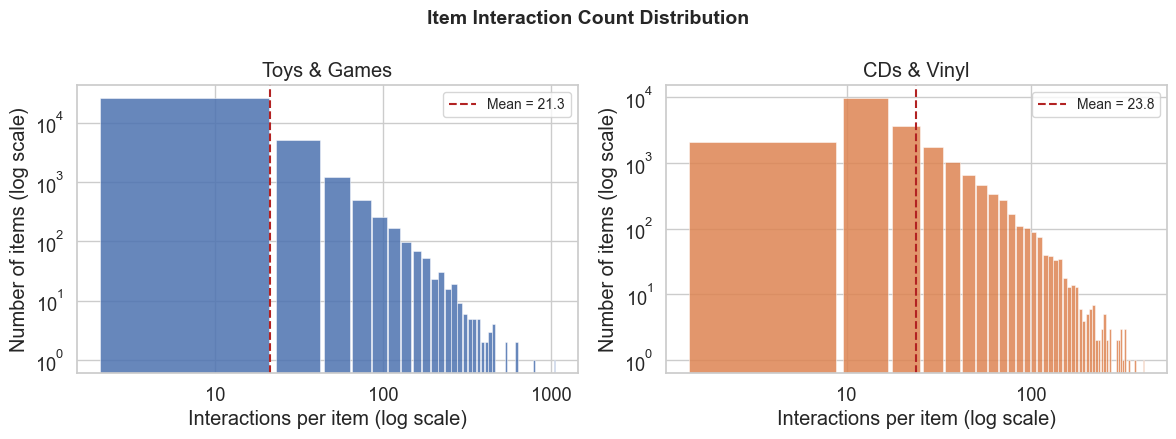

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (label, ds) in zip(axes, datasets.items()):
    item_counts = ds.train.groupby("item_idx")["user_idx"].count()
    counts, bins = np.histogram(item_counts, bins=50)
    bin_centers  = (bins[:-1] + bins[1:]) / 2
    ax.bar(bin_centers, counts, width=(bins[1] - bins[0]) * 0.9,
           color=COLORS[label], alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Interactions per item (log scale)")
    ax.set_ylabel("Number of items (log scale)")
    ax.set_title(label)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    mean_val = item_counts.mean()
    ax.axvline(mean_val, color="firebrick", linestyle="--", linewidth=1.5,
               label=f"Mean = {mean_val:.1f}")
    ax.legend(fontsize=10)

fig.suptitle("Item Interaction Count Distribution", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "item_degree_distribution.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "item_degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. User Activity Inequality (Lorenz Curve)

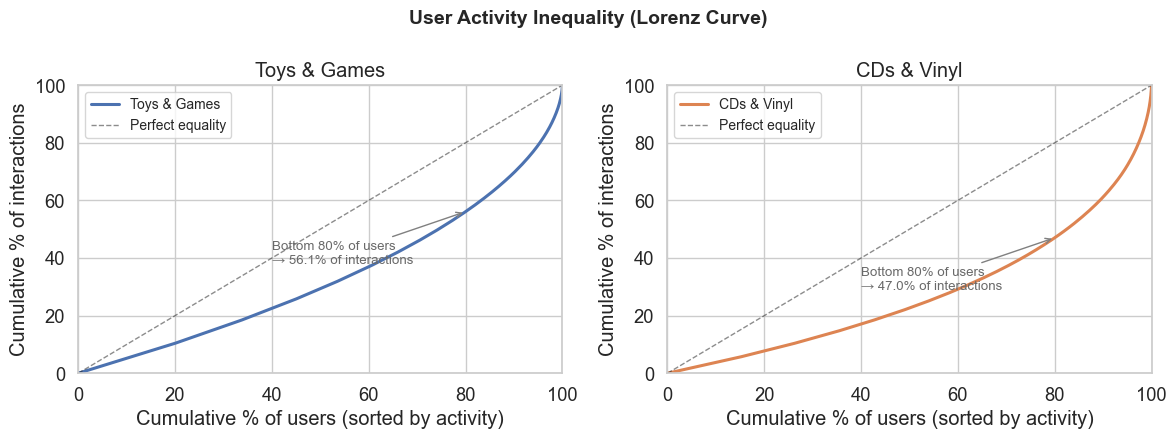

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (label, ds) in zip(axes, datasets.items()):
    user_counts = ds.train.groupby("user_idx")["item_idx"].count().sort_values()
    cumulative_users = np.linspace(0, 100, len(user_counts))
    cumulative_inter = np.cumsum(user_counts.values) / user_counts.sum() * 100

    ax.plot(cumulative_users, cumulative_inter,
            color=COLORS[label], linewidth=2.2, label=label)
    ax.plot([0, 100], [0, 100], "k--", linewidth=1, alpha=0.5, label="Perfect equality")

    idx_80   = np.searchsorted(cumulative_users, 80)
    pct_at_80 = cumulative_inter[idx_80]
    ax.annotate(f"Bottom 80% of users\n→ {pct_at_80:.1f}% of interactions",
                xy=(80, pct_at_80), xytext=(40, pct_at_80 - 18),
                arrowprops=dict(arrowstyle="->", color="gray"),
                fontsize=9.5, color="dimgray")

    ax.set_xlabel("Cumulative % of users (sorted by activity)")
    ax.set_ylabel("Cumulative % of interactions")
    ax.set_title(label)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

fig.suptitle("User Activity Inequality (Lorenz Curve)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lorenz_curve.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "lorenz_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Train / Validation / Test Split Sizes

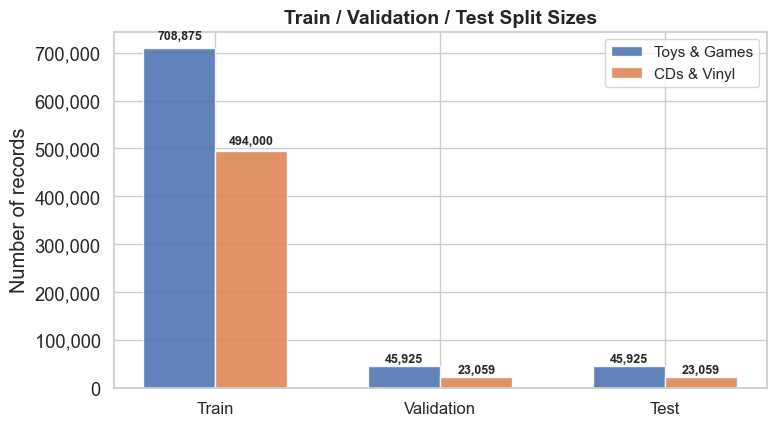

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
split_labels = ["Train", "Validation", "Test"]
x = np.arange(len(split_labels))
width = 0.32

for i, (label, ds) in enumerate(datasets.items()):
    sizes = [len(ds.train), len(ds.val), len(ds.test)]
    bars  = ax.bar(x + (i - 0.5) * width, sizes, width,
                   label=label, color=COLORS[label], alpha=0.88, edgecolor="white")
    for bar, val in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f"{val:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(split_labels, fontsize=12)
ax.set_ylabel("Number of records")
ax.set_title("Train / Validation / Test Split Sizes", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "split_sizes.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "split_sizes.png", dpi=150, bbox_inches="tight")
plt.show()